# Training Notebook — Vision Transformer on MNIST
## Investigating Gradient Flow via Orthogonal Initialization

**Author:** Nikolaos Mavros — University of Thessaly, ECE452  
**Repo:** `vit-gradient-flow`

This notebook trains two lightweight ViT models on MNIST and compares:
1. **Xavier/Glorot** initialization (baseline)
2. **Orthogonal** initialization ($W^TW = I$, experimental)

For each, we track: loss, accuracy, gradient norms per layer, and Jacobian condition numbers through the attention blocks.



## 1. Environment Setup

Make sure you're running this from the repo root where `Project.toml` lives.  
The cell below activates the project environment and installs any missing packages.

In [2]:
using Pkg
Pkg.activate("..")   # repo root (one level up from notebooks/)
Pkg.instantiate()

using Flux
using Flux: onehotbatch, onecold, logitcrossentropy, DataLoader
using Zygote
using MLDatasets
using LinearAlgebra
using Statistics
using Random
using JLD2
using ProgressMeter

println("All packages loaded ✓")

  Activating project at `c:\Users\nickb\Documents\vit-gradient-flow`


All packages loaded ✓


## 2. Hyperparameters

With `D_MODEL=64`, `NUM_BLOCKS=2`, and 16 patches, the model has ~120K parameters.  


In [3]:
# ── Image & Patch geometry ────────────────────────────────────────────────
const IMG_SIZE      = 28          # MNIST 28×28
const PATCH_SIZE    = 7           # 7×7 patches → 4×4 grid
const NUM_PATCHES   = (IMG_SIZE ÷ PATCH_SIZE)^2   # 16
const PATCH_DIM     = PATCH_SIZE * PATCH_SIZE      # 49

# ── Transformer architecture ─────────────────────────────────────────────
const D_MODEL       = 64          # embedding dim
const NUM_HEADS     = 4           # attention heads
const HEAD_DIM      = D_MODEL ÷ NUM_HEADS          # 16
const MLP_HIDDEN    = 128         # FFN hidden dim
const NUM_BLOCKS    = 2           # encoder blocks
const NUM_CLASSES   = 10          # digits 0–9

# ── Training ─────────────────────────────────────────────────────────────
const BATCH_SIZE    = 128
const EPOCHS        = 15
const LR            = 1e-3
const WEIGHT_DECAY  = 1e-4

# ── Diagnostics ──────────────────────────────────────────────────────────
const JACOBIAN_EVERY = 5          # compute Jacobian κ every N epochs

# ── Output directory ─────────────────────────────────────────────────────
const OUT_DIR = joinpath("..", "results")
mkpath(joinpath(OUT_DIR, "figures"))
mkpath(joinpath(OUT_DIR, "logs"))

println("Hyperparameters set ✓")
println("  Patches per image: $NUM_PATCHES  |  Patch dim: $PATCH_DIM")
println("  Model dim: $D_MODEL  |  Heads: $NUM_HEADS  |  Blocks: $NUM_BLOCKS")

Hyperparameters set ✓
  Patches per image: 16  |  Patch dim: 49
  Model dim: 64  |  Heads: 4  |  Blocks: 2


## 3. Initialization Strategies

Two strategies from the proposal:

- **Xavier/Glorot**: scales by $\sqrt{6 / (\text{fan\_in} + \text{fan\_out})}$ — standard default.
- **Orthogonal**: uses QR decomposition to produce a matrix with all singular values = 1.  
  This is the key hypothesis: orthogonal weights should preserve gradient norms through layers, yielding Jacobian condition numbers closer to 1.

In [4]:
function xavier_init(rng::AbstractRNG, dims...)
    fan_in  = dims[end-1] isa Integer ? dims[end-1] : prod(dims[1:end-1])
    fan_out = dims[end]
    limit   = Float32(sqrt(6.0 / (fan_in + fan_out)))
    return (rand(rng, Float32, dims...) .- 0.5f0) .* 2.0f0 .* limit
end
xavier_init(dims...) = xavier_init(Random.default_rng(), dims...)

function orthogonal_init(rng::AbstractRNG, dims...)
    rows, cols = dims[1], dims[2]
    n = max(rows, cols)
    A = randn(rng, Float32, n, n)
    Q, _ = qr(A)
    Q_mat = Matrix{Float32}(Q)
    return Q_mat[1:rows, 1:cols]
end
orthogonal_init(dims...) = orthogonal_init(Random.default_rng(), dims...)

# Quick sanity check — orthogonal matrix should have singular values ≈ 1
W_test = orthogonal_init(64, 64)
sv = svdvals(W_test)
println("Orthogonal init sanity check:")
println("  Singular values range: [$(round(minimum(sv); digits=4)), $(round(maximum(sv); digits=4))]")
println("  WᵀW ≈ I check (Frobenius norm of WᵀW - I): $(round(norm(W_test' * W_test - I); digits=6))")

Orthogonal init sanity check:
  Singular values range: [1.0, 1.0]
  WᵀW ≈ I check (Frobenius norm of WᵀW - I): 3.0e-6


## 4. Model Components

All layers are built manually (not using Flux's built-in `MultiHeadAttention`) so we have full access to `WQ`, `WK`, `WV`, `WO` for gradient inspection and Jacobian analysis.

### 4.1 Patch Embedding

Flattened 7×7 patches are linearly projected into `D_MODEL` dimensions.  
A learnable CLS token is prepended, and learnable positional embeddings are added.

In [5]:
struct PatchEmbedding
    proj::Dense                               # PATCH_DIM → D_MODEL
    cls_token::AbstractArray{Float32, 2}      # (D_MODEL, 1)
    pos_embed::AbstractArray{Float32, 2}      # (D_MODEL, NUM_PATCHES + 1)
end

Flux.@layer PatchEmbedding

function PatchEmbedding(init_fn)
    # Flux Dense(weight, bias): weight must be (out, in) = (D_MODEL, PATCH_DIM)
    proj = Dense(init_fn(D_MODEL, PATCH_DIM), zeros(Float32, D_MODEL))
    cls  = randn(Float32, D_MODEL, 1) .* 0.02f0
    pos  = randn(Float32, D_MODEL, NUM_PATCHES + 1) .* 0.02f0
    return PatchEmbedding(proj, cls, pos)
end

function (pe::PatchEmbedding)(patches)
    # patches: (PATCH_DIM, NUM_PATCHES, batch)
    B = size(patches, 3)
    x = pe.proj(reshape(patches, PATCH_DIM, :))          # (D_MODEL, NUM_PATCHES*B)
    x = reshape(x, D_MODEL, NUM_PATCHES, B)              # (D_MODEL, NUM_PATCHES, B)
    cls_expanded = repeat(pe.cls_token, 1, 1, B)          # (D_MODEL, 1, B)
    x = cat(cls_expanded, x; dims=2)                      # (D_MODEL, NUM_PATCHES+1, B)
    x = x .+ pe.pos_embed                                 # broadcast over batch
    return x
end

println("PatchEmbedding defined ✓")

PatchEmbedding defined ✓


### 4.2 Multi-Head Self-Attention

Implements scaled dot-product attention:

$$\text{Attn}(X) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

with separate `WQ`, `WK`, `WV`, `WO` weight matrices — exactly as described in the proposal's Equation (3).

In [6]:
struct MultiHeadAttention
    wq::Dense
    wk::Dense
    wv::Dense
    wo::Dense
end

Flux.@layer MultiHeadAttention

function MultiHeadAttention(init_fn)
    # Dense(weight, bias): weight is (out, in) = (D_MODEL, D_MODEL)
    wq = Dense(init_fn(D_MODEL, D_MODEL), zeros(Float32, D_MODEL))
    wk = Dense(init_fn(D_MODEL, D_MODEL), zeros(Float32, D_MODEL))
    wv = Dense(init_fn(D_MODEL, D_MODEL), zeros(Float32, D_MODEL))
    wo = Dense(init_fn(D_MODEL, D_MODEL), zeros(Float32, D_MODEL))
    return MultiHeadAttention(wq, wk, wv, wo)
end

function (mha::MultiHeadAttention)(x)
    # x: (D_MODEL, seq_len, batch)
    D, S, B = size(x)

    # Linear projections
    Q = mha.wq(reshape(x, D, :))    # (D_MODEL, S*B)
    K = mha.wk(reshape(x, D, :))
    V = mha.wv(reshape(x, D, :))

    # Reshape to multi-head: (HEAD_DIM, S, NUM_HEADS, B)
    Q = permutedims(reshape(Q, HEAD_DIM, NUM_HEADS, S, B), (1, 3, 2, 4))
    K = permutedims(reshape(K, HEAD_DIM, NUM_HEADS, S, B), (1, 3, 2, 4))
    V = permutedims(reshape(V, HEAD_DIM, NUM_HEADS, S, B), (1, 3, 2, 4))

    # Merge head+batch dims for batched matmul
    Q_flat = reshape(Q, HEAD_DIM, S, NUM_HEADS * B)
    K_flat = reshape(K, HEAD_DIM, S, NUM_HEADS * B)
    V_flat = reshape(V, HEAD_DIM, S, NUM_HEADS * B)

    # Scaled dot-product: (S, S, H*B)
    scale = Float32(1.0 / sqrt(HEAD_DIM))
    scores = Flux.batched_mul(
        permutedims(Q_flat, (2, 1, 3)),    # (S, HEAD_DIM, H*B)
        K_flat                              # (HEAD_DIM, S, H*B)
    ) .* scale

    attn_weights = softmax(scores; dims=2)  # (S, S, H*B)

    # Weighted sum: (HEAD_DIM, S, H*B)
    out = Flux.batched_mul(V_flat, permutedims(attn_weights, (2, 1, 3)))

    # Reshape back: (D_MODEL, S, B)
    out = reshape(permutedims(reshape(out, HEAD_DIM, S, NUM_HEADS, B), (1, 3, 2, 4)),
                  D_MODEL, S, B)

    # Output projection
    out_flat = mha.wo(reshape(out, D_MODEL, :))
    return reshape(out_flat, D_MODEL, S, B)
end

println("MultiHeadAttention defined ✓")

MultiHeadAttention defined ✓


### 4.3 Feed-Forward Network & Transformer Block

Each block uses **pre-norm** residual connections:

```
x = x + Attn(LayerNorm(x))
x = x + FFN(LayerNorm(x))
```

In [7]:
# ── Feed-Forward Network ──────────────────────────────────────────────────
struct FeedForward
    fc1::Dense
    fc2::Dense
end

Flux.@layer FeedForward

function FeedForward(init_fn)
    # fc1: (MLP_HIDDEN, D_MODEL),  fc2: (D_MODEL, MLP_HIDDEN)
    fc1 = Dense(init_fn(MLP_HIDDEN, D_MODEL), zeros(Float32, MLP_HIDDEN), gelu)
    fc2 = Dense(init_fn(D_MODEL, MLP_HIDDEN), zeros(Float32, D_MODEL))
    return FeedForward(fc1, fc2)
end

function (ff::FeedForward)(x)
    D, S, B = size(x)
    h = ff.fc1(reshape(x, D, :))
    h = ff.fc2(h)
    return reshape(h, D, S, B)
end

# ── Transformer Block ────────────────────────────────────────────────────
struct TransformerBlock
    ln1::LayerNorm
    attn::MultiHeadAttention
    ln2::LayerNorm
    ff::FeedForward
end

Flux.@layer TransformerBlock

function TransformerBlock(init_fn)
    return TransformerBlock(
        LayerNorm(D_MODEL),
        MultiHeadAttention(init_fn),
        LayerNorm(D_MODEL),
        FeedForward(init_fn)
    )
end

function (tb::TransformerBlock)(x)
    D, S, B = size(x)

    # Self-attention + residual
    x_norm = reshape(tb.ln1(reshape(x, D, :)), D, S, B)
    x = x .+ tb.attn(x_norm)

    # FFN + residual
    x_norm2 = reshape(tb.ln2(reshape(x, D, :)), D, S, B)
    x = x .+ tb.ff(x_norm2)

    return x
end

println("FeedForward & TransformerBlock defined ✓")

FeedForward & TransformerBlock defined ✓


### 4.4 Full Vision Transformer

Combines: PatchEmbedding → N × TransformerBlock → LayerNorm → Classification Head.  
The CLS token (position 1) is used for classification, following the original ViT design.

In [8]:
struct ViT
    patch_embed::PatchEmbedding
    blocks::Vector{TransformerBlock}
    ln_final::LayerNorm
    head::Dense
end

Flux.@layer ViT

function ViT(init_fn)
    pe     = PatchEmbedding(init_fn)
    blocks = [TransformerBlock(init_fn) for _ in 1:NUM_BLOCKS]
    ln     = LayerNorm(D_MODEL)
    # head: (NUM_CLASSES, D_MODEL)
    head   = Dense(init_fn(NUM_CLASSES, D_MODEL), zeros(Float32, NUM_CLASSES))
    return ViT(pe, blocks, ln, head)
end

function (model::ViT)(patches)
    # patches: (PATCH_DIM, NUM_PATCHES, batch)
    x = model.patch_embed(patches)           # (D_MODEL, NUM_PATCHES+1, B)
    for block in model.blocks
        x = block(x)
    end
    cls = x[:, 1, :]                         # CLS token → (D_MODEL, B)
    cls = model.ln_final(cls)
    logits = model.head(cls)                 # (NUM_CLASSES, B)
    return logits
end

println("ViT defined ✓")

ViT defined ✓


## 5. Data Loading — MNIST as Patch Sequences

MNIST images (28×28) are split into a 4×4 grid of 7×7 patches, each flattened to a 49-dim vector. This converts each image into a sequence of 16 tokens — the input format for the ViT.

In [ ]:
function images_to_patches(images)
    # images: (28, 28, batch) Float32
    B = size(images, 3)
    n_per_side = IMG_SIZE ÷ PATCH_SIZE
    patches = zeros(Float32, PATCH_DIM, NUM_PATCHES, B)

    idx = 1
    for row in 1:n_per_side
        for col in 1:n_per_side
            r_s = (row - 1) * PATCH_SIZE + 1
            c_s = (col - 1) * PATCH_SIZE + 1
            patch = @view images[r_s:r_s+PATCH_SIZE-1, c_s:c_s+PATCH_SIZE-1, :]
            patches[:, idx, :] .= reshape(patch, PATCH_DIM, B)
            idx += 1
        end
    end
    return patches
end

# ── Load MNIST ───────────────────────────────────────────────────────────
train_x, train_y = MLDatasets.MNIST(split=:train)[:]
test_x,  test_y  = MLDatasets.MNIST(split=:test)[:]

train_x = Float32.(train_x)
test_x  = Float32.(test_x)

train_labels = onehotbatch(train_y, 0:9)
test_labels  = onehotbatch(test_y,  0:9)

train_patches = images_to_patches(train_x)
test_patches  = images_to_patches(test_x)

train_loader = DataLoader((train_patches, train_labels);
                           batchsize=BATCH_SIZE, shuffle=true, partial=false)
test_loader  = DataLoader((test_patches, test_labels);
                           batchsize=BATCH_SIZE, shuffle=false, partial=true)

println("Weights loaded ✓")
println("  Xavier     parameters: $(sum(length, Flux.trainables(model_xavier)))")
println("  Orthogonal parameters: $(sum(length, Flux.trainables(model_ortho)))")

Data loaded ✓
  Train: 60000 images → patches (49, 16, 60000)
  Test:  10000 images → patches (49, 16, 10000)


## 6. Gradient Flow Diagnostics

Two diagnostic tools from the proposal:

1. **Gradient norm tracking** — records $\|\nabla_{W}\mathcal{L}\|_2$ for every trainable parameter each epoch. Vanishing → norms collapse to 0 in early layers; exploding → norms blow up.

2. **Jacobian condition number** — for a single sample, computes the Jacobian of each transformer block's output w.r.t. its input, then $\kappa(J) = \sigma_{\max} / \sigma_{\min}$. Orthogonal init should yield $\kappa \approx 1$.

In [ ]:
function collect_gradient_norms(grads, model)
    norms = Dict{String, Float64}()
    function _walk(prefix, g)
        if g isa AbstractArray{<:Number}
            norms[prefix] = Float64(norm(vec(g)))
        elseif g isa NamedTuple
            for k in keys(g)
                _walk(prefix == "" ? string(k) : prefix * "." * string(k), g[k])
            end
        elseif g isa AbstractArray || g isa Tuple
            for (i, item) in enumerate(g)
                _walk(prefix * "[$i]", item)
            end
        end
    end
    _walk("", grads)
    return norms
end

function compute_jacobian_condition(model, sample_patches)
    cond_numbers = Float64[]
    x = model.patch_embed(sample_patches)

    for (i, block) in enumerate(model.blocks)
        x_vec = vec(x)
        J = Zygote.jacobian(z -> vec(block(reshape(z, size(x)))), x_vec)[1]

        if J !== nothing && !isempty(J)
            sv = svdvals(J)
            sv_pos = filter(s -> s > 1e-10, sv)
            if length(sv_pos) >= 2
                push!(cond_numbers, Float64(sv_pos[1] / sv_pos[end]))
            else
                push!(cond_numbers, NaN)
            end
        else
            push!(cond_numbers, NaN)
        end
        x = block(x) 
    end
    return cond_numbers
end

function accuracy(model, loader)
    correct = 0; total = 0
    for (x, y) in loader
        ŷ = model(x)
        correct += sum(onecold(ŷ) .== onecold(y))
        total   += size(y, 2)
    end
    return correct / total
end

println("Diagnostics defined ✓")

Diagnostics defined ✓


## 7. Training Loop

Trains a ViT model with AdamW and logs all metrics. Saves weights + logs as `.jld2` files.

In [ ]:
function train_model!(model, train_loader, test_loader, tag::String)
    opt_state = Flux.setup(AdamW(LR, (0.9, 0.999), WEIGHT_DECAY), model)

    log = Dict{String, Vector}(
        "epoch"          => Int[],
        "train_loss"     => Float64[],
        "train_acc"      => Float64[],
        "test_acc"       => Float64[],
        "grad_norms"     => Dict{String, Float64}[],
        "jacobian_conds" => Vector{Float64}[],
    )

    sample_x, _ = first(train_loader)
    jac_sample   = sample_x[:, :, 1:1]

    for epoch in 1:EPOCHS
        epoch_loss  = 0.0
        num_batches = 0
        last_grad_norms = Dict{String, Float64}()

        @info "[$tag] Epoch $epoch / $EPOCHS"
        
        p = Progress(length(train_loader); desc="  Training: ")

        for (x, y) in train_loader
            loss_val, grads = Flux.withgradient(model) do m
                logitcrossentropy(m(x), y)
            end
            Flux.update!(opt_state, model, grads[1])

            epoch_loss  += loss_val
            num_batches += 1
            last_grad_norms = collect_gradient_norms(grads[1], model)
            
            next!(p)
        end

        avg_loss  = epoch_loss / num_batches
        train_acc = accuracy(model, train_loader)
        test_acc  = accuracy(model, test_loader)

        jac_conds = Float64[]
        if epoch == 1 || epoch % JACOBIAN_EVERY == 0 || epoch == EPOCHS
            @info "  Computing Jacobian condition numbers..."
            jac_conds = compute_jacobian_condition(model, jac_sample)
            for (i, κ) in enumerate(jac_conds)
                @info "    Block $i condition number: $(round(κ; digits=2))"
            end
        end

        @info "  Loss: $(round(avg_loss; digits=4))  Train: $(round(100*train_acc; digits=2))%  Test: $(round(100*test_acc; digits=2))%"

        push!(log["epoch"],          epoch)
        push!(log["train_loss"],     avg_loss)
        push!(log["train_acc"],      train_acc)
        push!(log["test_acc"],       test_acc)
        push!(log["grad_norms"],     last_grad_norms)
        push!(log["jacobian_conds"], jac_conds)
    end

   # --- Save weights (Using robust functional save) ---
    weight_path = joinpath(OUT_DIR, "vit_weights_$(tag).jld2")
    model_state = Flux.state(model)
    jldsave(weight_path; model_state=model_state)
    @info "[$tag] Weights saved to $weight_path"

    # --- Save training log (Using robust functional save) ---
    log_path = joinpath(OUT_DIR, "logs", "training_log_$(tag).jld2")
    jldsave(log_path; log=log)
    @info "[$tag] Log saved to $log_path"

    return log
end

println("Training function defined ✓")

Training function defined ✓


## 8. Experiment 1 — Xavier/Glorot Initialization (Baseline)

In [ ]:
using Random 

Random.seed!(42)
model_xavier = ViT(xavier_init)

n_params = sum(length, Flux.trainables(model_xavier))
println("ViT (Xavier) — $n_params parameters")

log_xavier = train_model!(model_xavier, train_loader, test_loader, "xavier")

┌ Warning: `Flux.params(m...)` is deprecated. Use `Flux.trainable(model)` for parameter collection,
│ and the explicit `gradient(m -> loss(m, x, y), model)` for gradient computation.
└ @ Flux C:\Users\nickb\.julia\packages\Flux\DZYiO\src\deprecations.jl:93


ViT (Xavier) — 72074 parameters


┌ Info: [xavier] Epoch 1 / 15
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:21
  Training: 100%|███████████████████████████████████████| Time: 0:01:58
┌ Info:   Computing Jacobian condition numbers...
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:46
┌ Info:     Block 1 condition number: 1.34975792e8
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:49
┌ Info:     Block 2 condition number: 3873.07
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:49
┌ Info:   Loss: 0.5907  Train: 92.35%  Test: 92.34%
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:53
┌ Info: [xavier] Epoch 2 / 15
└ @ Main c:\Us

Dict{String, Vector} with 6 entries:
  "train_loss"     => [0.590681, 0.200776, 0.137123, 0.111199, 0.0943179, 0.077…
  "train_acc"      => [0.923494, 0.958367, 0.961388, 0.975361, 0.976345, 0.9779…
  "test_acc"       => [0.9234, 0.952, 0.9528, 0.9647, 0.9648, 0.9678, 0.9685, 0…
  "epoch"          => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  "jacobian_conds" => [[1.34976e8, 3873.07], Float64[], Float64[], Float64[], […
  "grad_norms"     => [Dict("blocks[2].ln2.diag.scale"=>0.0414092, "blocks[2].f…

## 9. Experiment 2 — Orthogonal Initialization ($W^TW = I$)

In [ ]:
using Random 

Random.seed!(42)
model_ortho = ViT(orthogonal_init)

n_params_ortho = sum(length, Flux.trainables(model_ortho))
println("ViT (Orthogonal) — $n_params_ortho parameters")

log_ortho = train_model!(model_ortho, train_loader, test_loader, "orthogonal")

┌ Warning: `Flux.params(m...)` is deprecated. Use `Flux.trainable(model)` for parameter collection,
│ and the explicit `gradient(m -> loss(m, x, y), model)` for gradient computation.
└ @ Flux C:\Users\nickb\.julia\packages\Flux\DZYiO\src\deprecations.jl:93


ViT (Orthogonal) — 72074 parameters


┌ Info: [orthogonal] Epoch 1 / 15
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:21
  Training: 100%|███████████████████████████████████████| Time: 0:01:40
┌ Info:   Computing Jacobian condition numbers...
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:46
┌ Info:     Block 1 condition number: 2.9097915e6
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:49
┌ Info:     Block 2 condition number: 910.77
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:49
┌ Info:   Loss: 0.4896  Train: 93.65%  Test: 93.38%
└ @ Main c:\Users\nickb\Documents\vit-gradient-flow\notebooks\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X26sZmlsZQ==.jl:53
┌ Info: [orthogonal] Epoch 2 / 15
└ @ Main

Dict{String, Vector} with 6 entries:
  "train_loss"     => [0.489565, 0.178762, 0.125266, 0.09762, 0.0792673, 0.0680…
  "train_acc"      => [0.936532, 0.960587, 0.969635, 0.974242, 0.980702, 0.9826…
  "test_acc"       => [0.9338, 0.9531, 0.961, 0.9626, 0.9701, 0.9705, 0.9743, 0…
  "epoch"          => [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  "jacobian_conds" => [[2.90979e6, 910.774], Float64[], Float64[], Float64[], […
  "grad_norms"     => [Dict("blocks[2].ln2.diag.scale"=>0.0440716, "blocks[2].f…

## 10. Results Summary

In [13]:
using JLD2

# 1. Define the paths to the files we saved earlier
log_xavier_path = joinpath(OUT_DIR, "logs", "training_log_xavier.jld2")
log_ortho_path = joinpath(OUT_DIR, "logs", "training_log_orthogonal.jld2")

# 2. Load the specific "log" variable out of the saved files
log_xavier = load(log_xavier_path, "log")
log_ortho = load(log_ortho_path, "log")

println("="^70)
println("  TRAINING SUMMARY (LOADED FROM DISK)")
println("="^70)
println()

# 3. Print the results exactly as before
for (tag, log) in [("Xavier", log_xavier), ("Orthogonal", log_ortho)]
    ft = round(100 * log["train_acc"][end]; digits=2)
    fe = round(100 * log["test_acc"][end];  digits=2)
    fl = round(log["train_loss"][end]; digits=4)
    println("  [$tag]  Loss: $fl  |  Train: $ft%  |  Test: $fe%")

    jc = log["jacobian_conds"][end]
    if !isempty(jc)
        for (i, κ) in enumerate(jc)
            println("           Block $i Jacobian κ = $(round(κ; digits=2))")
        end
    end
    println()
end

println("="^70)
println("  Logs loaded from: $(joinpath(OUT_DIR, "logs"))/")
println("="^70)

  TRAINING SUMMARY (LOADED FROM DISK)

  [Xavier]  Loss: 0.0357  |  Train: 99.0%  |  Test: 97.13%
           Block 1 Jacobian κ = 8.980731e6
           Block 2 Jacobian κ = 18609.62

  [Orthogonal]  Loss: 0.03  |  Train: 98.88%  |  Test: 97.04%
           Block 1 Jacobian κ = 621788.62
           Block 2 Jacobian κ = 7200.58

  Logs loaded from: ..\results\logs/


## 11. Gradient Norm Comparison (Last Epoch)

Print side-by-side the gradient norms from the final training step of each model.  
Orthogonal init should show more uniform norms across layers (less vanishing).

In [21]:
using JLD2

# 1. Load the logs directly from disk (OUT_DIR is already safely locked in memory!)
log_xavier_path = joinpath(OUT_DIR, "logs", "training_log_xavier.jld2")
log_ortho_path = joinpath(OUT_DIR, "logs", "training_log_orthogonal.jld2")

log_xavier = load(log_xavier_path, "log")
log_ortho = load(log_ortho_path, "log")

# 2. Extract the gradient norms from the final epoch ([end])
gn_x = log_xavier["grad_norms"][end]
gn_o = log_ortho["grad_norms"][end]

# 3. FIX: Convert the Set to an Array so Julia can sort it
all_keys = sort(collect(union(keys(gn_x), keys(gn_o))))

println(rpad("Parameter", 40) * rpad("Xavier ∥∇∥", 15) * "Ortho ∥∇∥")
println("-"^70)

# 4. Print the comparison table
for k in all_keys
    vx = haskey(gn_x, k) ? round(gn_x[k]; digits=6) : "—"
    vo = haskey(gn_o, k) ? round(gn_o[k]; digits=6) : "—"
    println(rpad(k, 40) * rpad(string(vx), 15) * string(vo))
end

Parameter                               Xavier ∥∇∥     Ortho ∥∇∥
----------------------------------------------------------------------
blocks[1].attn.wk.bias                  0.0            0.0
blocks[1].attn.wk.weight                0.369592       0.275885
blocks[1].attn.wo.bias                  0.068454       0.139979
blocks[1].attn.wo.weight                0.354846       0.453131
blocks[1].attn.wq.bias                  0.052273       0.039459
blocks[1].attn.wq.weight                0.326249       0.227364
blocks[1].attn.wv.bias                  0.079678       0.153999
blocks[1].attn.wv.weight                0.339069       0.41241
blocks[1].ff.fc1.bias                   0.038952       0.060822
blocks[1].ff.fc1.weight                 0.353706       0.433376
blocks[1].ff.fc2.bias                   0.027118       0.071562
blocks[1].ff.fc2.weight                 0.296526       0.331055
blocks[1].ln1.diag.bias                 0.087168       0.207161
blocks[1].ln1.diag.scale              

## 12. Loss & Accuracy Curves

Simple text-based epoch log. 

In [22]:
# 1. Dynamically get the number of epochs directly from the saved log
num_epochs = length(log_xavier["epoch"])

# 2. Print the header
println(rpad("Epoch", 8) * rpad("Xavier Loss", 14) * rpad("Xavier Test%", 14) *
        rpad("Ortho Loss", 14) * "Ortho Test%")
println("-"^64)

# 3. Loop through the logs and print the timeline
for i in 1:num_epochs
    xl = round(log_xavier["train_loss"][i]; digits=4)
    xa = round(100 * log_xavier["test_acc"][i]; digits=2)
    
    ol = round(log_ortho["train_loss"][i]; digits=4)
    oa = round(100 * log_ortho["test_acc"][i]; digits=2)
    
    # Using string() ensures the padding works perfectly even with trailing zeros
    println(rpad(string(i), 8) * rpad(string(xl), 14) * rpad(string(xa, "%"), 14) * rpad(string(ol), 14) * string(oa, "%"))
end

Epoch   Xavier Loss   Xavier Test%  Ortho Loss    Ortho Test%
----------------------------------------------------------------
1       0.5907        92.34%        0.4896        93.38%
2       0.2008        95.2%         0.1788        95.31%
3       0.1371        95.28%        0.1253        96.1%
4       0.1112        96.47%        0.0976        96.26%
5       0.0943        96.48%        0.0793        97.01%
6       0.078         96.78%        0.068         97.05%
7       0.0721        96.85%        0.0614        97.43%
8       0.0634        96.73%        0.0527        97.38%
9       0.0539        96.81%        0.0516        97.12%
10      0.0542        96.95%        0.0433        97.42%
11      0.0463        97.3%         0.0423        97.34%
12      0.0424        97.24%        0.0352        96.96%
13      0.0373        96.96%        0.0351        97.36%
14      0.037         97.31%        0.0322        97.31%
15      0.0357        97.13%        0.03          97.04%


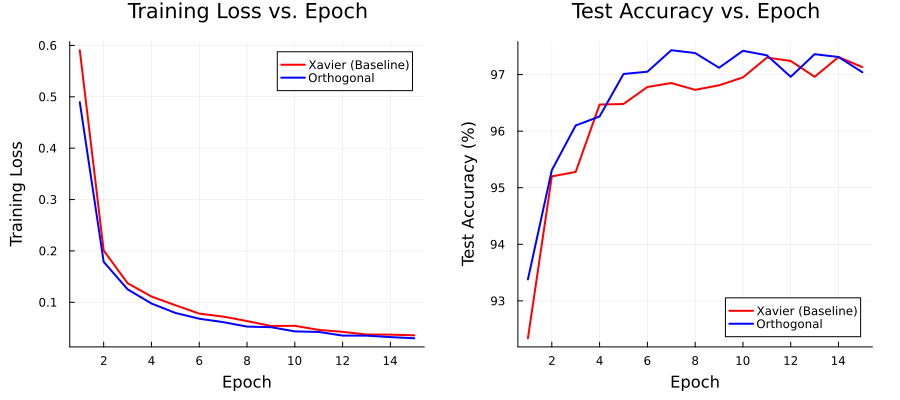

Saved publication figure to: ..\results\figures\loss_acc_curves.pdf


In [25]:
# You may need to run: Pkg.add("Plots") if you don't have it installed
using Plots

# 1. Extract the data arrays from your loaded logs
epochs = log_xavier["epoch"]
loss_x = log_xavier["train_loss"]
loss_o = log_ortho["train_loss"]

# Convert accuracy to percentages for the plot
acc_x = log_xavier["test_acc"] .* 100
acc_o = log_ortho["test_acc"] .* 100

# 2. Create the Training Loss plot
p1 = plot(epochs, loss_x, 
    label="Xavier (Baseline)", 
    linewidth=2, 
    color=:red, 
    xlabel="Epoch", 
    ylabel="Training Loss", 
    title="Training Loss vs. Epoch",
    grid=true
)
plot!(p1, epochs, loss_o, 
    label="Orthogonal", 
    linewidth=2, 
    color=:blue
)

# 3. Create the Test Accuracy plot
p2 = plot(epochs, acc_x, 
    label="Xavier (Baseline)", 
    linewidth=2, 
    color=:red, 
    xlabel="Epoch", 
    ylabel="Test Accuracy (%)", 
    title="Test Accuracy vs. Epoch",
    legend=:bottomright,
    grid=true
)
plot!(p2, epochs, acc_o, 
    label="Orthogonal", 
    linewidth=2, 
    color=:blue
)

# 4. Combine them side-by-side and save as a high-res PDF for your paper
fig = plot(p1, p2, layout=(1, 2), size=(900, 400), margin=5Plots.mm)
display(fig)

# Save as PDF (best for LaTeX/Word papers to prevent pixelation)
out_fig_path = joinpath(OUT_DIR, "figures", "loss_acc_curves.pdf")
savefig(fig, out_fig_path)
println("Saved publication figure to: $out_fig_path")